In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from IPython.display import display, Markdown

from shared.plot_utilities import setup_notebook_display
from shared.regression_utilities import run_regression_suite, plot_regression_coefficient_heatmap
from shared.stats_utilities import benjamini_hochberg, fdr_marker
from nuke.utils.load_replay_data import (
    CONDITION_FACTORS,
    REPLAY_TAG_JOIN_KEYS,
    canonical_condition_name,
    add_canonical_replay_model,
    add_condition_factor_columns,
    get_complete_replay_models,
    get_present_strategist_model_order,
    load_replay_data,
    prefixed_tier_columns,
    tier_source_columns,
)

setup_notebook_display()
df = load_replay_data()
df = add_canonical_replay_model(df)
df = add_condition_factor_columns(df)


✓ Loaded 40,560 rows from 104 files
  Conditions   : original, no-rationale, high-stakes, high-stakes-no-rationale, ethical, ethical-high-stakes, ethical-no-rationale, high-stakes-no-rationale-ethical
  Replay models: DeepSeek-V3.2, DeepSeek-V4, GLM-4.7, GLM-5.1, Gemini-3.5-Flash, Gemma-4, Kimi-K2.5, Kimi-K2.6, MiniMax-M2.7, Mistral-Small-4, Qwen-3.5, Qwen-3.6-27B, gpt-oss-120b

  Rows per condition × replay model:
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                         DeepSeek-V3.2       DeepSeek-V4           GLM-4.7           GLM-5.1  Gemini-3.5-Flash           Gemma-4         Kimi-K2.5         Kimi-K2.6      MiniMax-M2.7   Mistral-Small-4          Qwen-3.5      Qwen-3.6-27B      gpt-oss-120b             Total
  ─

**Multiple-comparison note (FDR).** The significance stars (`*` p<0.05, `**` p<0.01, `***` p<0.001) below use raw, uncorrected p-values. A Benjamini–Hochberg FDR pass is applied *within each table/figure* (the coefficients shown together form one family); coefficients that survive at q<0.05 are additionally marked with a dagger (`†`) next to the raw stars, and tidy tables gain `q_value` / `fdr_significance` columns. Because q ≥ p, a dagger only ever appears on a coefficient that already has a raw star.

## Regressions: `replay_use_nuke_delta`

Three nested models (main effects â†’ condition interactions â†’ model Ã— condition) with game/player fixed effects and cluster-robust SEs.

Baseline: GPT-OSS-120B, has rationale, not high-stakes, not ethical

[main] replay_use_nuke_delta ~ no_rationale + high_stakes + ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[interactions] replay_use_nuke_delta ~ no_rationale * high_stakes + no_rationale * ethical + high_stakes * ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[model_x_condition] replay_use_nuke_delta ~ (no_rationale + high_stakes + ethical) * C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)

Main Effects: Factor Contributions to Δ replay_use_nuke_delta
[baseline: GPT-OSS-120B, no no_rationale, no high_stakes, no ethical] SUMMARY

Statistically Significant Effects (p < 0.05):
----------------------------------------
  DeepSeek-3.2                   +15.914 [+13.800, +18.028] ***
  DeepSeek-4                     +6.639 [+4.435, +8.843] ***
  GLM-4.7                        +11.110 [+9.039, +13.181] ***
  GLM-5.1                        -4.198 [-6.302, -2.094] ***
  Gemini-3.5-Fla

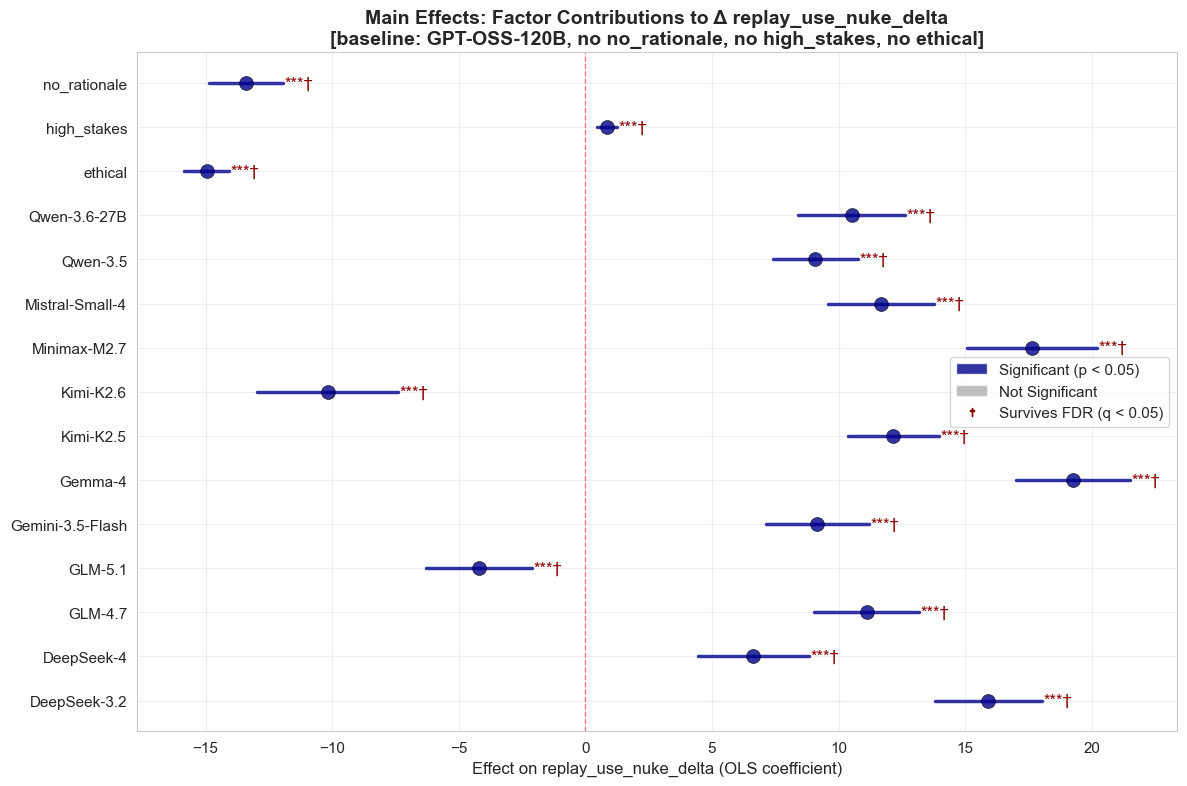

=== Main Effects (replay_use_nuke_delta) ===
                              OLS Regression Results                             
Dep. Variable:     replay_use_nuke_delta   R-squared:                       0.335
Model:                               OLS   Adj. R-squared:                  0.333
Method:                    Least Squares   F-statistic:                     112.0
Date:                   Wed, 08 Jul 2026   Prob (F-statistic):           2.95e-66
Time:                           11:21:23   Log-Likelihood:            -1.8558e+05
No. Observations:                  40560   AIC:                         3.715e+05
Df Residuals:                      40415   BIC:                         3.727e+05
Df Model:                            144                                         
Covariance Type:                 cluster                                         
R² = 0.3352, Adj R² = 0.3328, n = 40560, (cluster-robust SEs; FE: game_id, player_id)

With Interactions: Factor Contributions to Δ rep

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 144, but rank is 15
  warnings.warn('covariance of constraints does not have full '


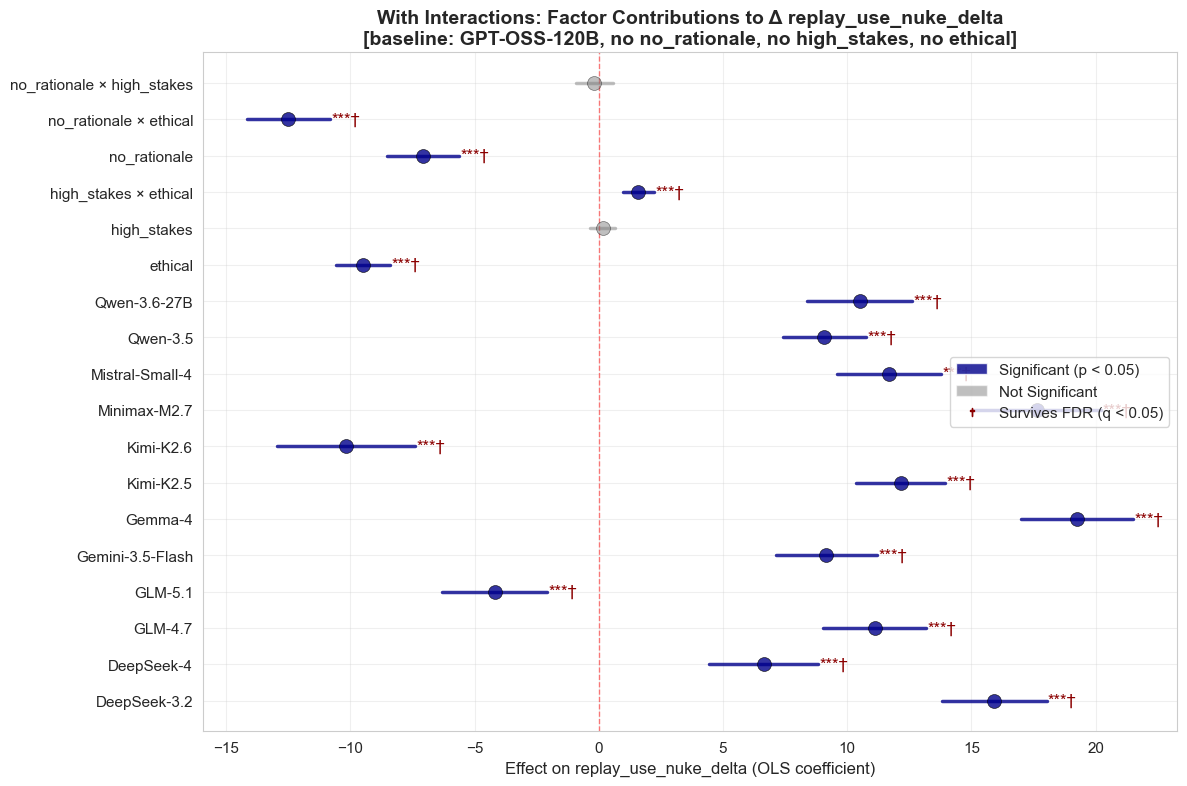

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 18
  warnings.warn('covariance of constraints does not have full '



=== Condition Interactions (replay_use_nuke_delta) ===
                              OLS Regression Results                             
Dep. Variable:     replay_use_nuke_delta   R-squared:                       0.347
Model:                               OLS   Adj. R-squared:                  0.345
Method:                    Least Squares   F-statistic:                     95.03
Date:                   Wed, 08 Jul 2026   Prob (F-statistic):           2.60e-65
Time:                           11:21:23   Log-Likelihood:            -1.8521e+05
No. Observations:                  40560   AIC:                         3.707e+05
Df Residuals:                      40412   BIC:                         3.720e+05
Df Model:                            147                                         
Covariance Type:                 cluster                                         
R² = 0.3471, Adj R² = 0.3448, n = 40560, (cluster-robust SEs; FE: game_id, player_id)

=== Model x Condition (replay_use_nuk

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 180, but rank is 51
  warnings.warn('covariance of constraints does not have full '


In [2]:
GROUP_COLS = ['game_id', 'player_id']

_ = run_regression_suite(
    data=df,
    outcome='replay_use_nuke_delta',
    condition_factors=CONDITION_FACTORS,
    group_cols=GROUP_COLS,
    fdr=True,
)


## Regressions: `replay_nuke_delta`

Same regression suite for the nuke (launch) outcome.

[main] replay_nuke_delta ~ no_rationale + high_stakes + ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[interactions] replay_nuke_delta ~ no_rationale * high_stakes + no_rationale * ethical + high_stakes * ethical + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)
[model_x_condition] replay_nuke_delta ~ (no_rationale + high_stakes + ethical) * C(replay_model_canonical, Treatment(reference="GPT-OSS-120B")) + C(_fe_group)

Main Effects: Factor Contributions to Δ replay_nuke_delta
[baseline: GPT-OSS-120B, no no_rationale, no high_stakes, no ethical] SUMMARY

Statistically Significant Effects (p < 0.05):
----------------------------------------
  DeepSeek-3.2                   +16.949 [+14.954, +18.943] ***
  DeepSeek-4                     +10.419 [+7.895, +12.942] ***
  GLM-4.7                        +14.700 [+12.655, +16.744] ***
  GLM-5.1                        +2.336 [+0.115, +4.556] *
  Gemini-3.5-Flash             

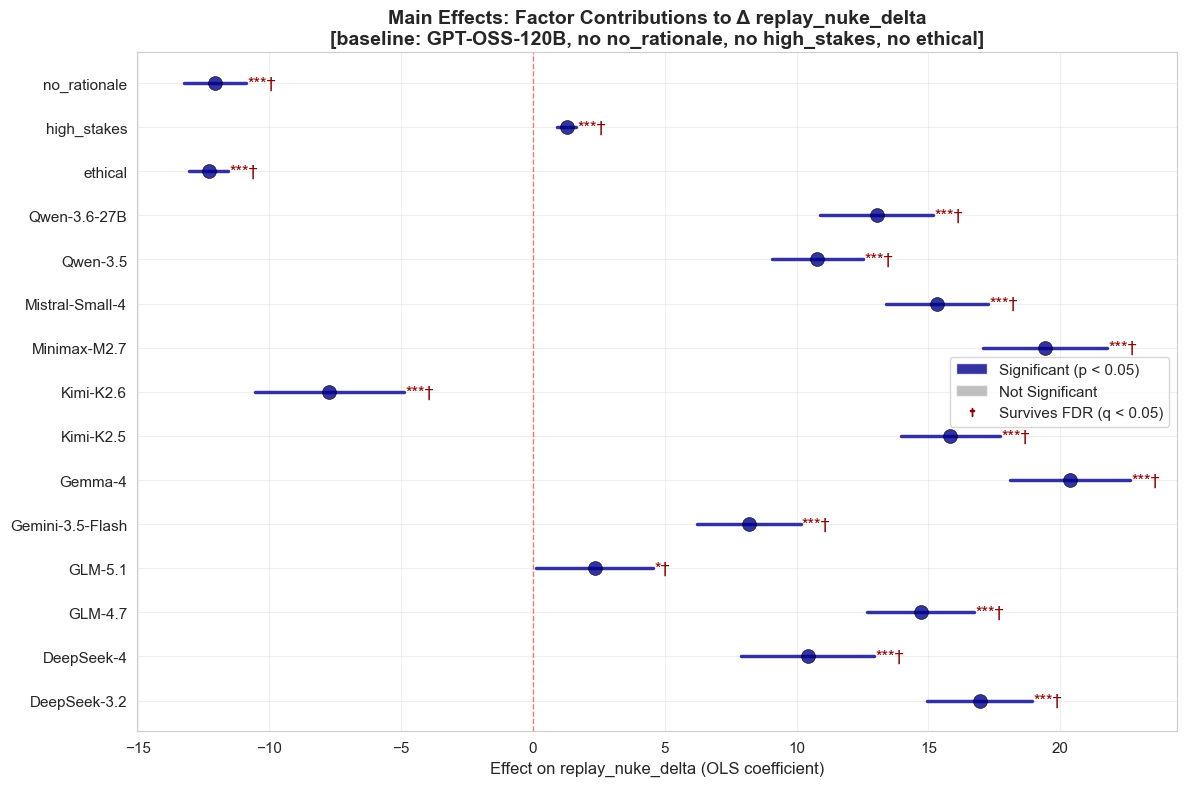

=== Main Effects (replay_nuke_delta) ===
                            OLS Regression Results                            
Dep. Variable:      replay_nuke_delta   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     107.0
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           4.35e-65
Time:                        11:21:25   Log-Likelihood:            -1.8479e+05
No. Observations:               40560   AIC:                         3.699e+05
Df Residuals:                   40415   BIC:                         3.711e+05
Df Model:                         144                                         
Covariance Type:              cluster                                         
R² = 0.2867, Adj R² = 0.2842, n = 40560, (cluster-robust SEs; FE: game_id, player_id)


c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 144, but rank is 15
  warnings.warn('covariance of constraints does not have full '



With Interactions: Factor Contributions to Δ replay_nuke_delta
[baseline: GPT-OSS-120B, no no_rationale, no high_stakes, no ethical] SUMMARY

Statistically Significant Effects (p < 0.05):
----------------------------------------
  DeepSeek-3.2                   +16.949 [+14.954, +18.943] ***
  DeepSeek-4                     +10.419 [+7.895, +12.942] ***
  GLM-4.7                        +14.700 [+12.655, +16.744] ***
  GLM-5.1                        +2.336 [+0.115, +4.556] *
  Gemini-3.5-Flash               +8.179 [+6.209, +10.150] ***
  Gemma-4                        +20.367 [+18.098, +22.636] ***
  Kimi-K2.5                      +15.836 [+13.939, +17.733] ***
  Kimi-K2.6                      -7.726 [-10.565, -4.887] ***
  Minimax-M2.7                   +19.417 [+17.065, +21.769] ***
  Mistral-Small-4                +15.325 [+13.379, +17.272] ***
  Qwen-3.5                       +10.785 [+9.065, +12.506] ***
  Qwen-3.6-27B                   +13.035 [+10.900, +15.170] ***
  ethical    

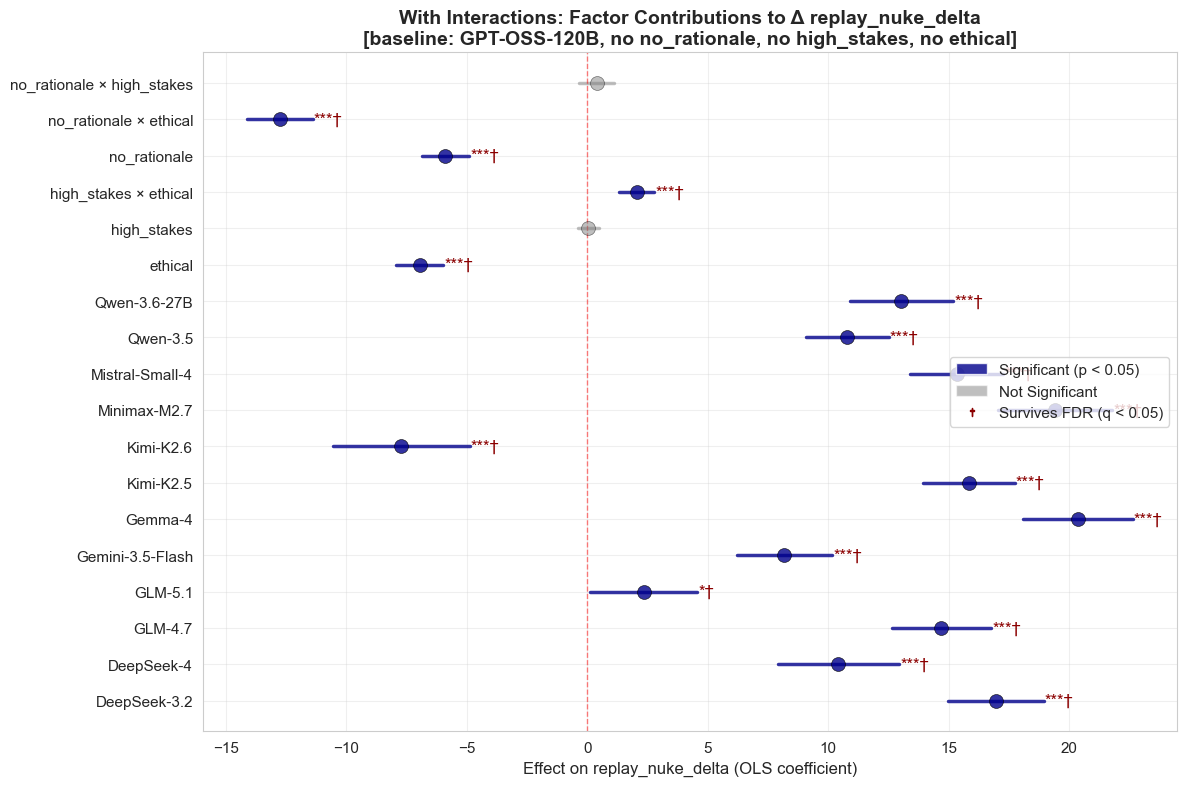


=== Condition Interactions (replay_nuke_delta) ===
                            OLS Regression Results                            
Dep. Variable:      replay_nuke_delta   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     104.0
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           1.18e-67
Time:                        11:21:26   Log-Likelihood:            -1.8439e+05
No. Observations:               40560   AIC:                         3.691e+05
Df Residuals:                   40412   BIC:                         3.703e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
R² = 0.3008, Adj R² = 0.2982, n = 40560, (cluster-robust SEs; FE: game_id, player_id)

=== Model x Condition (replay_nuke_delta) ===
                         

c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 18
  warnings.warn('covariance of constraints does not have full '
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 180, but rank is 51
  warnings.warn('covariance of constraints does not have full '


In [3]:
_ = run_regression_suite(
    data=df,
    outcome='replay_nuke_delta',
    condition_factors=CONDITION_FACTORS,
    group_cols=GROUP_COLS,
    fdr=True,
)

## Per-Model Factor Contributions

Separate OLS regressions per model with pairwise interactions:
`outcome ~ no_rationale * high_stakes + no_rationale * ethical + high_stakes * ethical`
with cluster-robust SEs.

Left panel shows main-effect and interaction coefficients with significance stars.
Right panel shows per-model RÂ².

### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


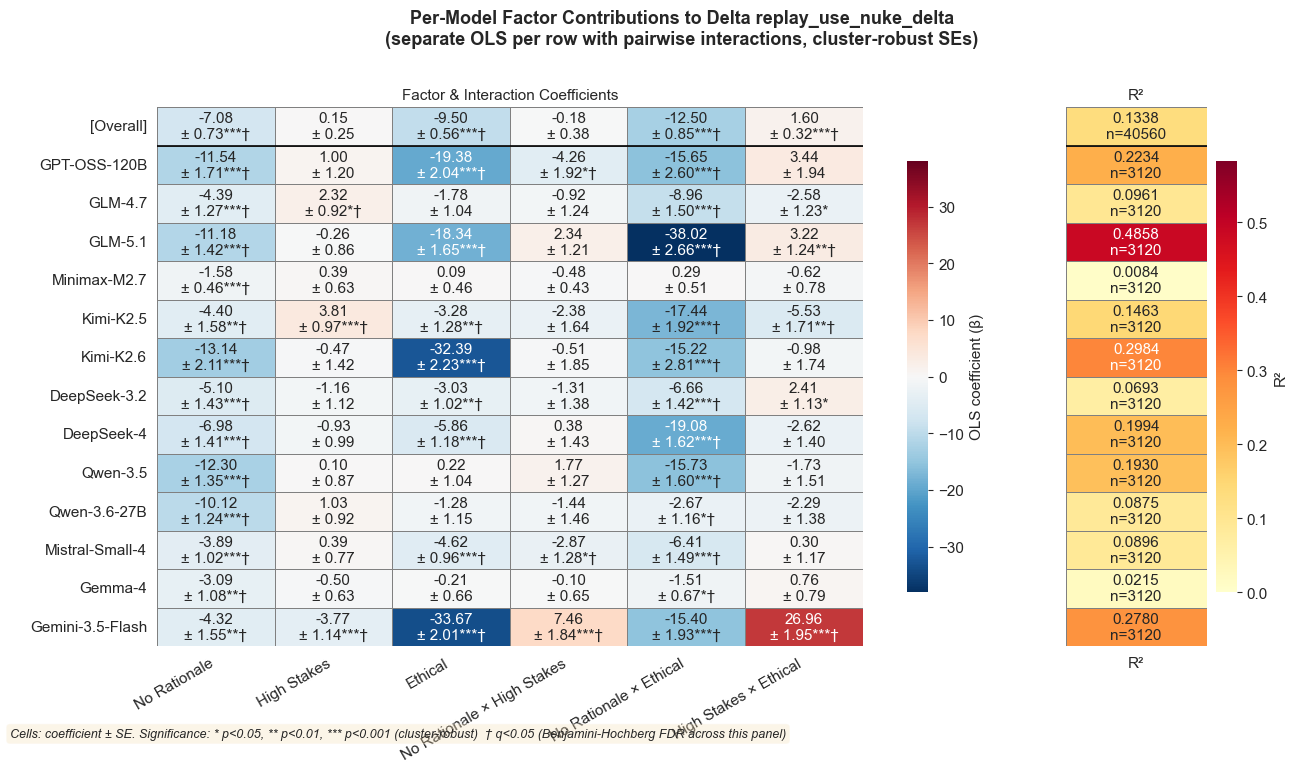

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


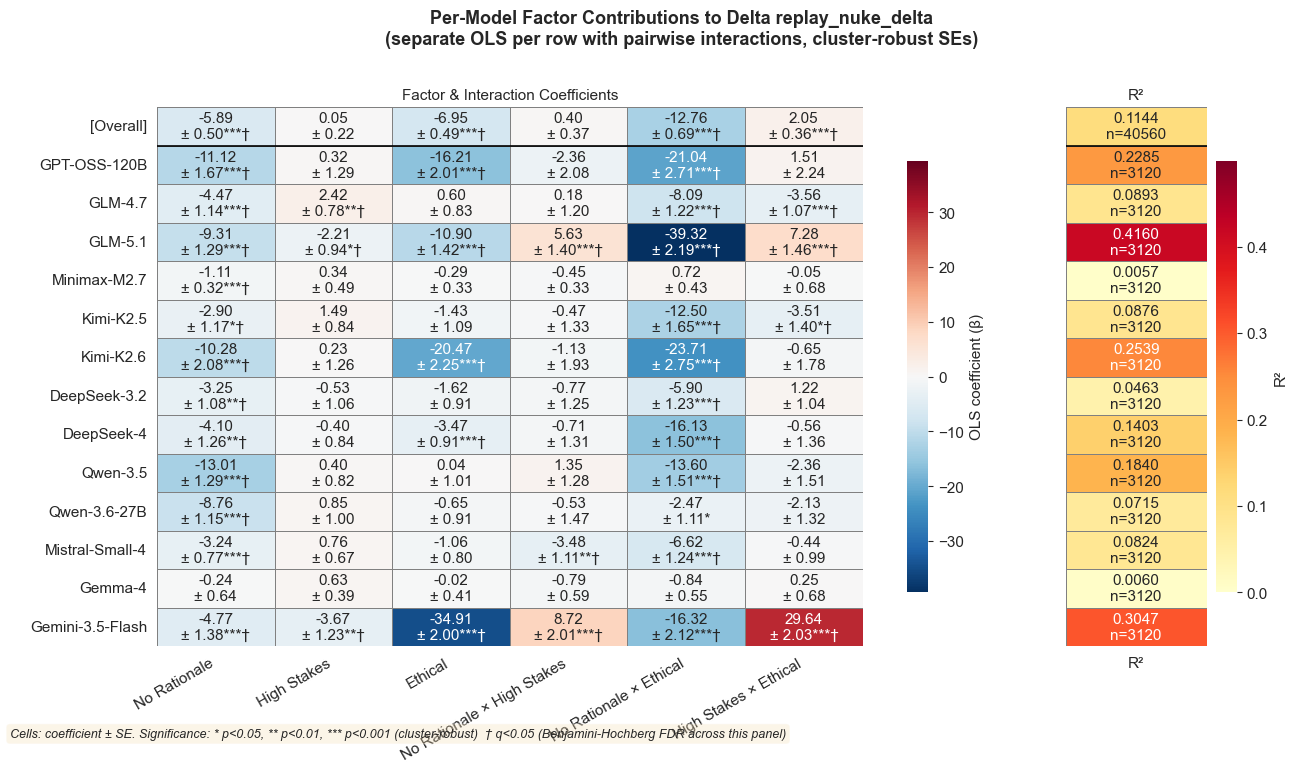

In [4]:
from itertools import combinations

model_order = get_present_strategist_model_order(df)
heatmap_model_order = get_complete_replay_models(df, model_order=model_order)
skipped = [model for model in model_order if model not in heatmap_model_order]
if skipped:
    print(f'Skipping models with incomplete condition sets: {", ".join(skipped)}')

interaction_names = [f'{a}:{b}' for a, b in combinations(CONDITION_FACTORS, 2)]
all_vars = CONDITION_FACTORS + interaction_names
pairs = ' + '.join(f'{a} * {b}' for a, b in combinations(CONDITION_FACTORS, 2))
formula_template = '{outcome} ~ ' + pairs

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df,
        outcome=outcome,
        predictors=all_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=formula_template.format(outcome=outcome),
        title=(
            f'Per-Model Factor Contributions to Delta {outcome}\n'
            f'(separate OLS per row with pairwise interactions, cluster-robust SEs)'
        ),
        coefficient_title='Factor & Interaction Coefficients',
        figsize=(14, 7),
        fdr=True,
    )


## Original Player Type: Briefed vs Simple

,rows
original_player_type,
Simple,31200
Briefed,9360


### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


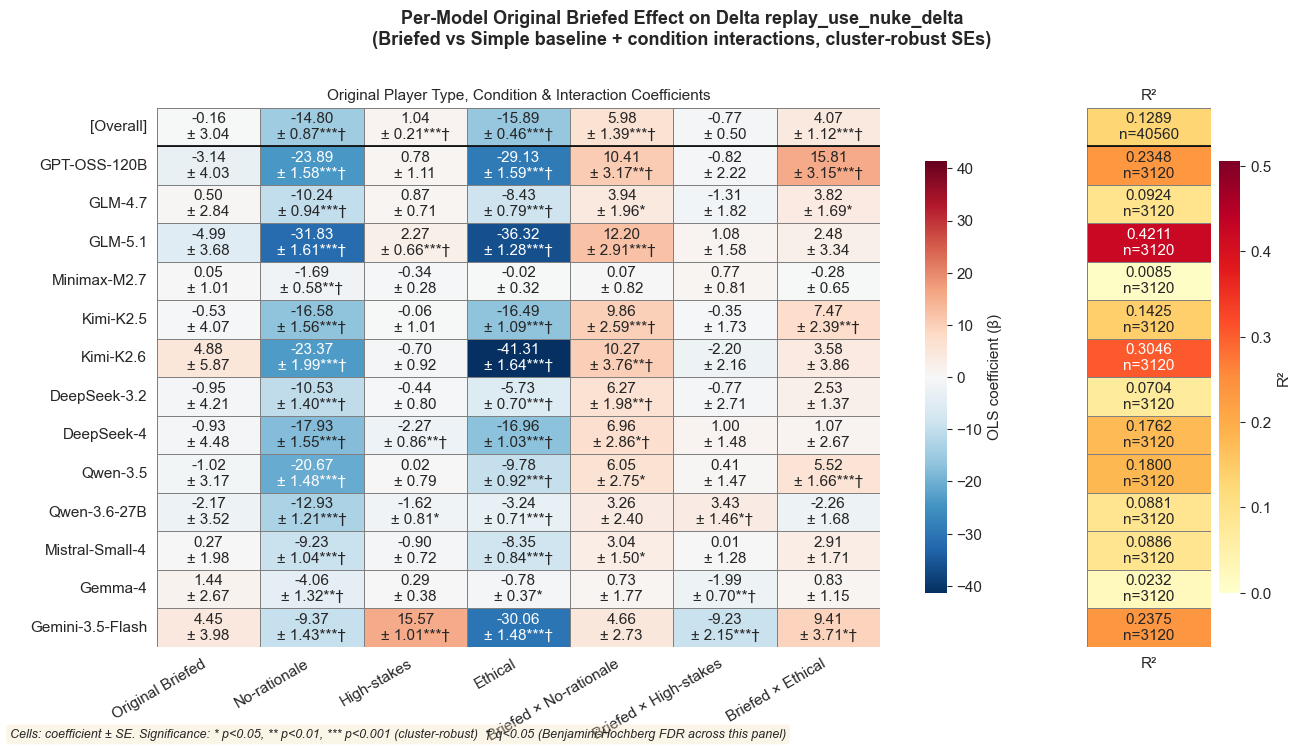

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


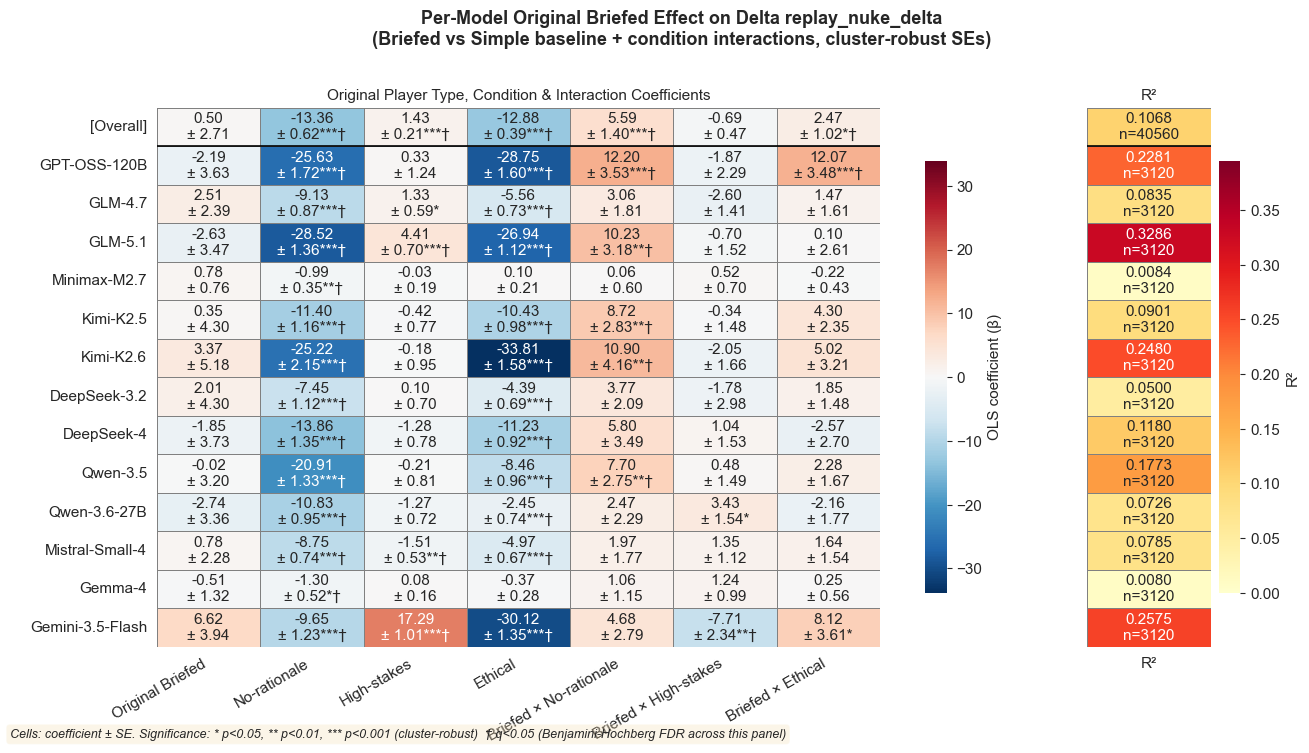

In [5]:
df_player_type = df.copy()
df_player_type['original_briefed'] = (
    df_player_type['player_type']
    .astype(str)
    .str.contains('Briefed', case=False, regex=False)
    .astype(int)
)

briefed_interaction_names = [
    f'original_briefed:{factor}' for factor in CONDITION_FACTORS
]
briefed_vars = ['original_briefed'] + CONDITION_FACTORS + briefed_interaction_names
briefed_formula_template = (
    '{outcome} ~ original_briefed * ('
    + ' + '.join(CONDITION_FACTORS)
    + ')'
)

BRIEFED_LABELS = {
    'original_briefed': 'Original Briefed',
    'no_rationale': 'No-rationale',
    'high_stakes': 'High-stakes',
    'ethical': 'Ethical',
    'original_briefed:no_rationale': 'Briefed × No-rationale',
    'original_briefed:high_stakes': 'Briefed × High-stakes',
    'original_briefed:ethical': 'Briefed × Ethical',
}

display(Markdown('## Original Player Type: Briefed vs Simple'))
display(
    df_player_type['player_type']
    .str.extract(r'-(Briefed|Simple)$')[0]
    .value_counts()
    .rename_axis('original_player_type')
    .to_frame('rows')
)

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df_player_type,
        outcome=outcome,
        predictors=briefed_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=briefed_formula_template.format(outcome=outcome),
        predictor_labels=BRIEFED_LABELS,
        title=(
            f'Per-Model Original Briefed Effect on Delta {outcome}\n'
            f'(Briefed vs Simple baseline + condition interactions, cluster-robust SEs)'
        ),
        coefficient_title='Original Player Type, Condition & Interaction Coefficients',
        figsize=(14, 7),
        fdr=True,
    )


## Per-Model Factor Contributions with Reasoning Tag Controls

Same per-model OLS as above, but with two additional binary predictors from the reasoning trail:
- **rea_tier_Explicit**: whether the model's reasoning contains explicit ethical/moral language
- **rea_tier_SimulationGame**: whether the reasoning references simulation/game framing

`outcome ~ no_rationale * high_stakes + no_rationale * ethical + high_stakes * ethical + rea_tier_Explicit + rea_tier_SimulationGame`

Rows after join: 40,560
rea_tier_Explicit prevalence:       18.9%
rea_tier_SimulationGame prevalence:  7.0%


### replay_use_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


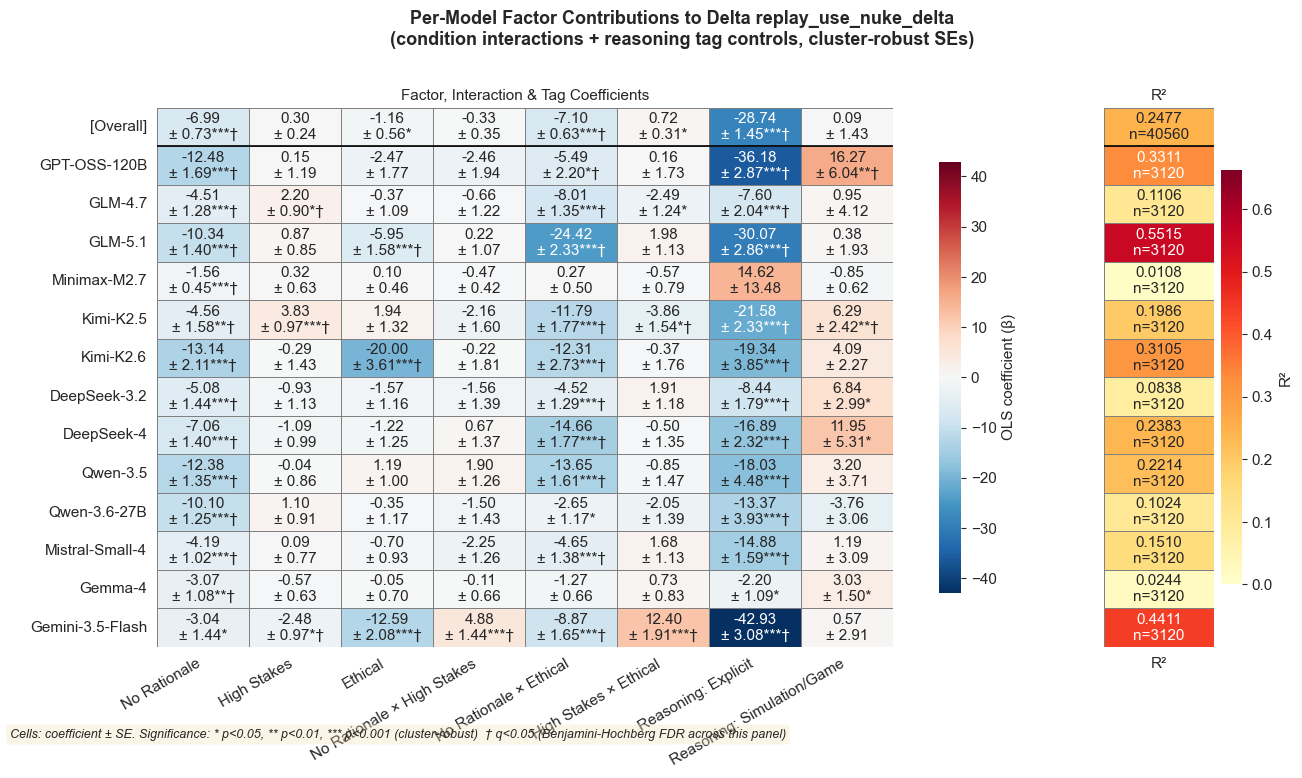

### replay_nuke_delta

f:\vox-deorum\nuke-analysis\nuke\..\shared\regression_utilities.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


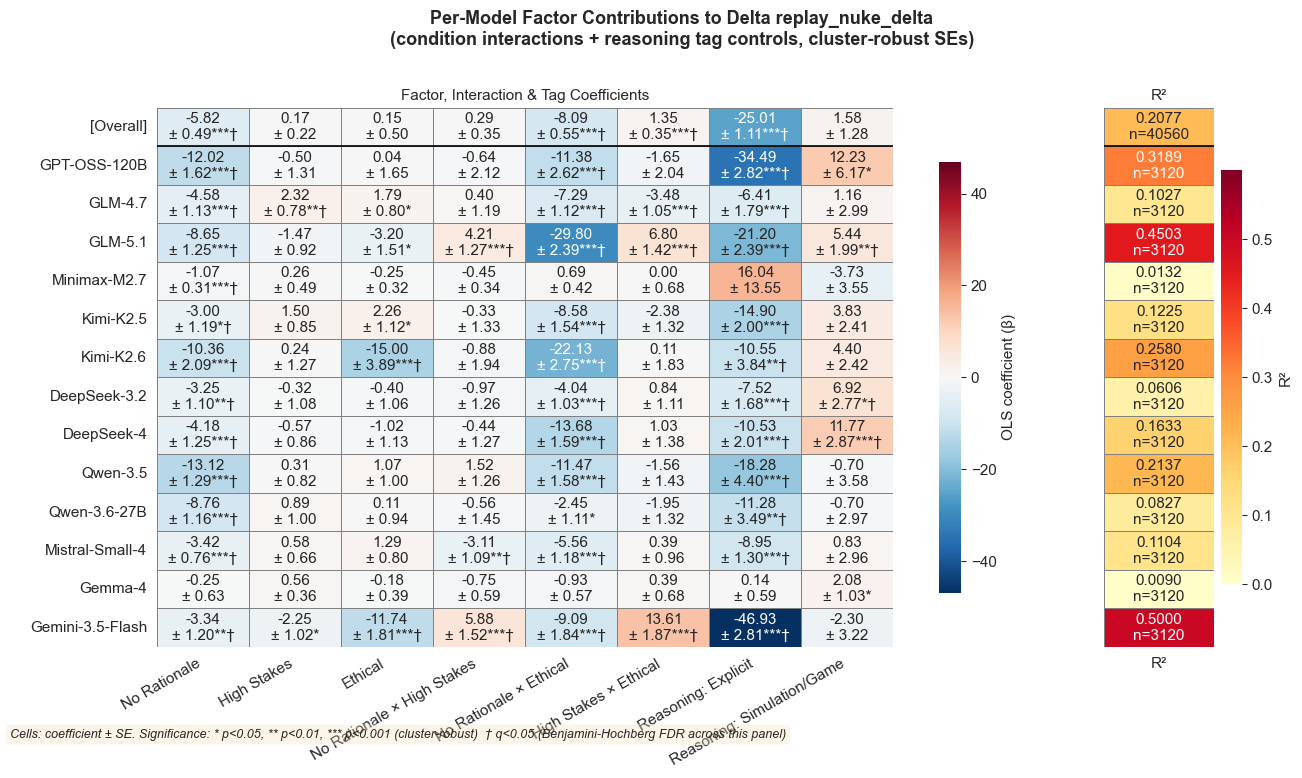

In [6]:
from pathlib import Path

# Load reasoning trail tags and join to df
rea = pd.read_csv(Path('trails') / 'reasoning_trails_tagged.csv')
rea['condition'] = rea['condition'].map(canonical_condition_name)
TAG_TIERS = ['Explicit', 'Simulation_Game']
TAG_COLS_ORIG = tier_source_columns(TAG_TIERS)
TAG_COLS = prefixed_tier_columns(TAG_TIERS, 'rea')

rea_tags = rea[REPLAY_TAG_JOIN_KEYS + TAG_COLS_ORIG].rename(columns=dict(zip(TAG_COLS_ORIG, TAG_COLS)))
df_tags = df.merge(rea_tags, on=REPLAY_TAG_JOIN_KEYS, how='left')
df_tags[TAG_COLS] = df_tags[TAG_COLS].fillna(0).astype(int)

print(f'Rows after join: {len(df_tags):,}')
print(f'rea_tier_Explicit prevalence:       {df_tags["rea_tier_Explicit"].mean():.1%}')
print(f'rea_tier_SimulationGame prevalence:  {df_tags["rea_tier_SimulationGame"].mean():.1%}')

# Extended predictors: condition factors + interactions + tag factors
tag_vars = TAG_COLS
extended_vars = all_vars + tag_vars
tag_terms = ' + '.join(tag_vars)
extended_formula_template = formula_template + ' + ' + tag_terms

TAG_LABELS = {
    'rea_tier_Explicit': 'Reasoning: Explicit',
    'rea_tier_SimulationGame': 'Reasoning: Simulation/Game',
}

for outcome in ['replay_use_nuke_delta', 'replay_nuke_delta']:
    display(Markdown(f'### {outcome}'))
    plot_regression_coefficient_heatmap(
        data=df_tags,
        outcome=outcome,
        predictors=extended_vars,
        group_cols=GROUP_COLS,
        model_order=heatmap_model_order,
        formula=extended_formula_template.format(outcome=outcome),
        predictor_labels=TAG_LABELS,
        title=(
            f'Per-Model Factor Contributions to Delta {outcome}\n'
            f'(condition interactions + reasoning tag controls, cluster-robust SEs)'
        ),
        coefficient_title='Factor, Interaction & Tag Coefficients',
        figsize=(14, 7),
        fdr=True,
    )


## Regression: Episode Civilization as Sum-Coded Predictor

OLS for `replay_use_nuke_delta` on the full replay sample after joining each episode's `civilization` from `panel_data.csv`. Civilization is sum-coded, so each civilization coefficient is interpreted as a deviation from the grand mean. Standard errors are clustered by game/player, but game/player fixed-effect dummies are omitted because civilization is constant within each game/player episode series.


In [7]:
from pathlib import Path
from shared.regression_utilities import fit_regression

panel_path = Path('..') / 'panel_data.csv'
if not panel_path.exists():
    panel_path = Path('panel_data.csv')

episode_civilization = (
    pd.read_csv(panel_path, usecols=['game_id', 'player_id', 'civilization'])
    .drop_duplicates(['game_id', 'player_id'])
)

df_civ = df.merge(
    episode_civilization,
    on=['game_id', 'player_id'],
    how='left',
    validate='many_to_one',
)
assert df_civ['civilization'].notna().all(), 'Missing civilization for at least one replay episode'

individual_game_counts = (
    df_civ[['game_id', 'player_id', 'civilization']]
    .drop_duplicates(['game_id', 'player_id'])
    ['civilization']
    .value_counts()
)

OUTCOME = 'replay_use_nuke_delta'
CIV_TERM = 'C(civilization, Sum)'
CIV_PREFIX = f'{CIV_TERM}[S.'
MODEL_TERM = 'C(replay_model_canonical, Treatment(reference="GPT-OSS-120B"))'
civilization_formula = (
    f'{OUTCOME} ~ prev_use_nuke + after_use_nuke + '
    + ' + '.join(CONDITION_FACTORS)
    + f' + {CIV_TERM}'
    + f' + {MODEL_TERM}'
)

display(Markdown('### Episode Civilization Sum-Coded Effect'))
display(
    individual_game_counts
    .rename_axis('civilization')
    .to_frame('n')
)

civilization_fit = fit_regression(
    civilization_formula,
    df_civ,
    outcome_col=OUTCOME,
    group_cols=GROUP_COLS,
)
print(f'[{OUTCOME}] {civilization_formula}')
print(
    f'R^2 = {civilization_fit.rsquared:.4f}, '
    f'Adj R^2 = {civilization_fit.rsquared_adj:.4f}, '
    f'n = {int(individual_game_counts.sum())} individual games, '
    f'replay rows = {civilization_fit.nobs}, '
    '(cluster-robust SEs)'
)

civilization_rows = []
for term in civilization_fit.params.index:
    if not term.startswith(CIV_PREFIX):
        continue
    civilization = term.split('[S.', 1)[1].rstrip(']')
    civilization_rows.append({
        'civilization': civilization,
        'coef': civilization_fit.params.get(term),
        'std_error': civilization_fit.bse.get(term),
        'p_value': civilization_fit.pvalues.get(term),
        'r_squared': civilization_fit.rsquared,
        'n': int(individual_game_counts.get(civilization, 0)),
    })

civilization_regression_results = pd.DataFrame(civilization_rows)
# Benjamini-Hochberg FDR across the civilization coefficients (one family = this table)
civilization_regression_results['q_value'] = benjamini_hochberg(
    civilization_regression_results['p_value']
)
civilization_regression_results['fdr_significance'] = (
    civilization_regression_results['q_value'].map(fdr_marker)
)
display(
    civilization_regression_results
    .sort_values('coef', key=lambda values: values.abs(), ascending=False)
    .style.format({
        'coef': '{:.3f}',
        'std_error': '{:.3f}',
        'p_value': '{:.3g}',
        'q_value': '{:.3g}',
        'r_squared': '{:.4f}',
    })
)


### Episode Civilization Sum-Coded Effect

,n
civilization,
Spain,7
The Netherlands,6
America,6
Assyria,6
The Iroquois,6
Songhai,6
Germany,5
Sweden,5
The Aztecs,5


[replay_use_nuke_delta] replay_use_nuke_delta ~ prev_use_nuke + after_use_nuke + no_rationale + high_stakes + ethical + C(civilization, Sum) + C(replay_model_canonical, Treatment(reference="GPT-OSS-120B"))
R^2 = 0.3020, Adj R^2 = 0.3010, n = 130 individual games, replay rows = 40560, (cluster-robust SEs)


,civilization,coef,std_error,p_value,r_squared,n,q_value,fdr_significance
11,Ethiopia,-13.518,3.080,1.14e-05,0.3020,1,9.1e-05,†
39,The Zulus,10.740,5.828,0.0654,0.3020,5,0.139,
1,Arabia,-8.518,3.080,0.00568,0.3020,1,0.0252,†
6,Byzantium,-7.973,3.080,0.00963,0.3020,1,0.0329,†
20,Persia,6.563,1.256,1.76e-07,0.3020,2,3.51e-06,†
15,India,-6.297,2.340,0.00712,0.3020,3,0.0285,†
19,Mongolia,6.282,1.694,0.000209,0.3020,3,0.0012,†
25,Russia,6.056,3.108,0.0514,0.3020,4,0.121,
24,Rome,-5.649,0.758,9.54e-14,0.3020,1,3.81e-12,†
17,Japan,4.972,1.063,2.91e-06,0.3020,3,2.91e-05,†
